In [10]:
from langgraph.graph import StateGraph,START,END    
from typing import TypedDict,Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import MemorySaver

In [2]:
from langgraph.graph.message import add_messages
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [3]:
llm = ChatOpenAI()
def chat_node(state: ChatState) -> ChatState:

    # take user query from state
    messages = state['messages']
    # send to LLM and get response
    response = llm.invoke(messages)
    # response store state
    return {'messages': [response] }

In [ ]:
checkpointer = MemorySaver()
graph = StateGraph(ChatState)

# add nodes

graph.add_node('chat_node',chat_node)

# add edges
graph.add_edge(START,'chat_node')
graph.add_edge('chat_node',END)

chatbot = graph.compile(checkpointer=checkpointer)

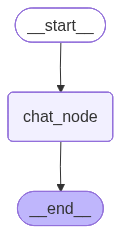

In [6]:
chatbot

In [8]:
initial_state = {
    'messages' : [HumanMessage(content="What is the capital of Pakistan")]
}
chatbot.invoke(initial_state)['messages'][-1].content

RateLimitError: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}

In [11]:
thread_id = '1'
while True:
    user_message = input("Type Here: ")
    print ("User:", user_message)
    if user_message.strip().lower() in ['exit','quit','bye']:
        break
    config = {'configurable':{'thread_id':thread_id}}
    response = chatbot.invoke({'messages': [HumanMessage(content=user_message)]}, config = config)
    print("AI:", response['messages'][-1].content)

User: hello my name is wardah


RateLimitError: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}

In [12]:
chatbot.get_state(config=config)

ValueError: No checkpointer set